In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [60]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
import os
importlib.reload(GCN)

def plot_or_save(label1, label2, version, save = False):

    if not os.path.exists(f'filtered_data/{label1}_{label2}_X_val.npy'):
        raise FileNotFoundError(f"Label not founnd")


    if save:
        folder_path = f'pictures/{label1}_{label2}'
        os.makedirs(folder_path, exist_ok=True)


    types = ['val', 'train']
    error = [0, 0]
    data = [None]*4
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f'Defect Energy Actual vs Predictions', fontsize=24)

    for index, t_val in enumerate(types):

        # Load validation data
        data_x = np.load(f'filtered_data/{label1}_{label2}_X_{t_val}.npy')
        data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_{t_val}.npy')
        data_y = np.load(f'filtered_data/{label1}_{label2}_y_{t_val}.npy')

        norm = np.load(f'filtered_data/{label1}_{label2}_norm_params.npy')

        # Convert to tensors
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        X_val_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
        adj_val_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
        y_val_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

        model = GCN.GraphConv(20, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()


        # Prepare validation dataset for prediction
        val_graphs = []
        for i in range(len(X_val_tensor)):
            edge_index, _ = dense_to_sparse(adj_val_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
            data = Data(x=X_val_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
            val_graphs.append(data)

        # Predict on validation set
        preds = []
        with torch.no_grad():
            for data in val_graphs:
                x = data.x
                edge_index = data.edge_index
                batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
                pred = model(x, data.edge_index, data.edge_weight, batch)
                preds.append(pred.cpu().numpy().flatten()[0])
                #preds.append(0.5)

        preds = np.array(preds)
        y_true = y_val_tensor.cpu().numpy().flatten()

        converted_preds = preds * (norm[1] - norm[0]) + norm[0]
        converted_y_true = y_true * (norm[1] - norm[0]) + norm[0]

        #data[index * 2 + 0] = preds
        #data[index * 2 + 1] = y_true


        ax = axes[index]
        sns.scatterplot(x=converted_y_true, y=converted_preds, ax=ax, color='blue', alpha=0.6, s=50)
        ax.set_xlabel('Actual (eV)', fontsize=18)
        ax.set_ylabel('Predicted (eV)', fontsize=18)
        if index == 0:
            ax.set_title(f'Testing', fontsize=20)
        else:
            ax.set_title(f'Training', fontsize=20)
        
        ax.plot([converted_y_true.min(), converted_y_true.max()], [converted_y_true.min(), converted_y_true.max()], 'r--', linewidth=2, label='Perfect Prediction')
        #ax.grid(False, linestyle='--', alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.legend(fontsize=16)
        
        
        residuals = preds - y_true

        error[index] = np.mean(residuals**2)  # RMSE in original scale

    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/corr_{version}.png', dpi=300, bbox_inches='tight')

    plt.show()

    return
        # Plot residuals
    fig_res, axes_res = plt.subplots(1, 2, figsize=(16, 7))

    # Plot residuals
    sns.histplot(residuals, bins=100, kde=True, ax=axes_res[0])
    axes_res[0].set_xlabel('Residual (Predicted - Actual)')
    axes_res[0].set_title(f'Residuals for {label1}_{label2}')

    # Plot actual data distribution
    sns.histplot(y_true, bins=100, kde=True, ax=axes_res[1])
    axes_res[1].set_xlabel('Actual Values')
    axes_res[1].set_title(f'Actual Data Distribution for {label1}_{label2}')

    plt.tight_layout()

    if save:
        plt.savefig(f'pictures/{label1}_{label2}/residuals_{version}.png', dpi=300)

    plt.show()

    amount = len(y_true)

    random_guess_error = 0
    for i in range(amount):
        random_guess = np.random.uniform(0, 1)
        random_guess_error += (random_guess - y_true[i])**2

    random_guess_error /= amount

    mean_guess = np.mean(y_true)
    mean_guess_error = np.mean((mean_guess - y_true) ** 2)


    #prediction_power_mean = random_guess_error / mean_guess_error
    prediction_power_val = random_guess_error / error[0]  # Using validation RMSE
    prediction_power_train = random_guess_error / error[1]  # Using training RMSE
    

    # Bar plot of prediction power
    fig_power, ax_power = plt.subplots(figsize=(10, 6))
    ax_power.bar(['Baseline'], [1], color='lightgray', alpha=0.7, label='Baseline')
    #ax_power.bar(['Mean Guess'], [prediction_power_mean], color='salmon', label='Mean Guess')
    ax_power.bar(['Prediction Power (Val)'], [prediction_power_val], color='skyblue', label='Model (Val)')
    ax_power.bar(['Prediction Power (Train)'], [prediction_power_train], color='lightgreen', label='Model (Train)')
    ax_power.set_ylabel('Prediction Power')
    ax_power.set_title(f'Prediction Power for {label1}_{label2}')
    ax_power.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/power_{version}.png', dpi=300)
    plt.show()


    print(f"error: {mean_guess_error}, {error[0]}, {error[1]}")
    



/tmp/ipykernel_1004/2953206243.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

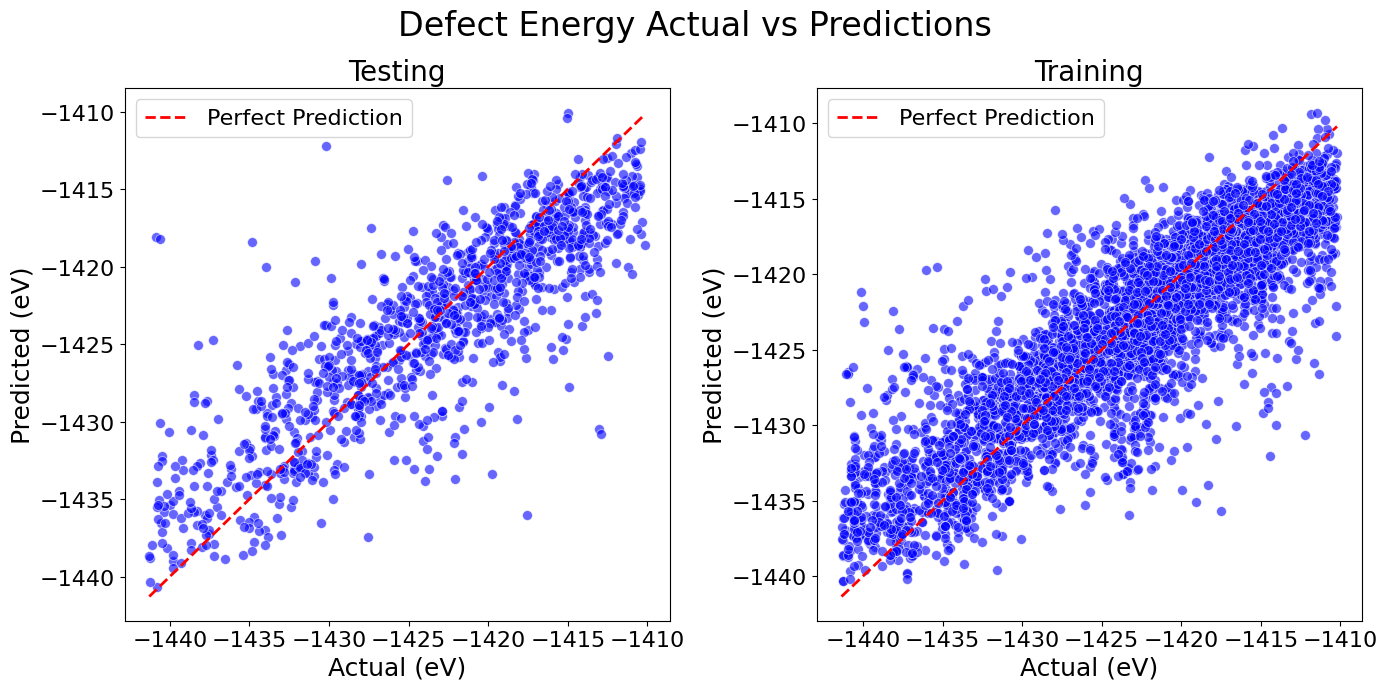

In [61]:
import importlib
import os
importlib.reload(GCN)
plot_or_save("hse-gs", "defect_total_energy", "2.0", save=True)

/tmp/ipykernel_1004/1539601669.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

[(np.float32(2.443691), np.float32(9.211093)), (np.float32(2.1192198), np.float32(2.5617862)), (np.float32(2.9204924), np.float32(2.9366336)), (np.float32(4.184944), np.float32(4.2012916)), (np.float32(1.9743942), np.float32(3.1368544))]


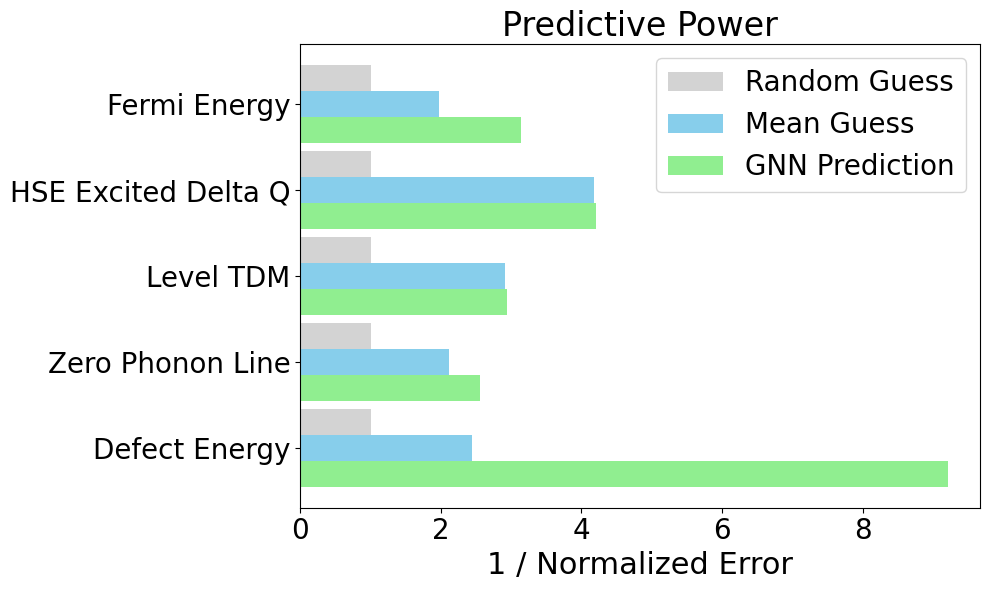

In [37]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
import os
importlib.reload(GCN)

def computePowers(label1, label2, version, save = False):


    # Load validation data
    data_x = np.load(f'filtered_data/{label1}_{label2}_X_val.npy')
    data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_val.npy')
    data_y = np.load(f'filtered_data/{label1}_{label2}_y_val.npy')

    # Convert to tensors
    #device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    device = torch.device('cpu')
    X_val_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
    adj_val_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
    y_val_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

    model = GCN.GraphConv(20, 0.001).to(device)
    model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
    model.eval()

    # Prepare validation dataset for prediction
    val_graphs = []
    for i in range(len(X_val_tensor)):
        edge_index, _ = dense_to_sparse(adj_val_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
        data = Data(x=X_val_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
        val_graphs.append(data)

    # Predict on validation set
    preds = []
    with torch.no_grad():
        for data in val_graphs:
            x = data.x
            edge_index = data.edge_index
            batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
            pred = model(x, data.edge_index, data.edge_weight, batch)
            preds.append(pred.cpu().numpy().flatten()[0])
            #preds.append(0.5)

    preds = np.array(preds)
    y_true = y_val_tensor.cpu().numpy().flatten()
    residuals = preds - y_true

    amount = len(y_true)

    random_guess_error = 0
    for i in range(amount):
        random_guess = np.random.uniform(0, 1)
        random_guess_error += (random_guess - y_true[i])**2

    random_guess_error /= amount

    mean_guess = np.mean(y_true)
    mean_guess_error = np.mean((mean_guess - y_true) ** 2)

    prediction_power_mean = random_guess_error / mean_guess_error
    prediction_power_val = random_guess_error / np.mean(residuals**2)  # RMSE in original scale
    #prediction_power_train = random_guess_error / error[1]  # Using training RMSE
    

    return (prediction_power_mean, prediction_power_val)


powers = []

for label1, label2, version in [('hse-gs', 'defect_total_energy', '2.1'), 
                                ("hse-ex1", "defect_zero_phonon_line", "2.0"), 
                                ('hse-gs', 'defect_lvl_tdm', '2.0'),
                                ('hse-ex1', 'defect_hse_excited_deltaQ', '2.0'),
                                ('hse-gs', 'defect_fermi_energy', '2.0')]:
    powers.append(computePowers(label1, label2, version, save=True))

print(powers)
# Labels for the bars
labels = ['Defect Energy', 'Zero Phonon Line', 'Level TDM', 'HSE Excited Delta Q', 'Fermi Energy']

# Extract mean and val powers
mean_powers = [p[0] for p in powers]
val_powers = [p[1] for p in powers]

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(labels))

ax.barh([y + 0.3 for y in y_pos], [1] * len(labels), height=0.3, label='Random Guess', color='lightgray')
ax.barh([y for y in y_pos], mean_powers, height=0.3, label='Mean Guess', color='skyblue')
ax.barh([y - 0.3 for y in y_pos], val_powers, height=0.3, label='GNN Prediction', color='lightgreen')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=20)
ax.set_xlabel('1 / Normalized Error', fontsize=22)
ax.set_title('Predictive Power', fontsize=24)
ax.tick_params(axis='x', labelsize=20)
ax.legend(fontsize=20)
plt.tight_layout()
plt.savefig('pictures/predictive_power.png', dpi=300)
plt.show()

/tmp/ipykernel_1004/336933996.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1004/336933996.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1004/336933996.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1004/336933996.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1004/336933996.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists 

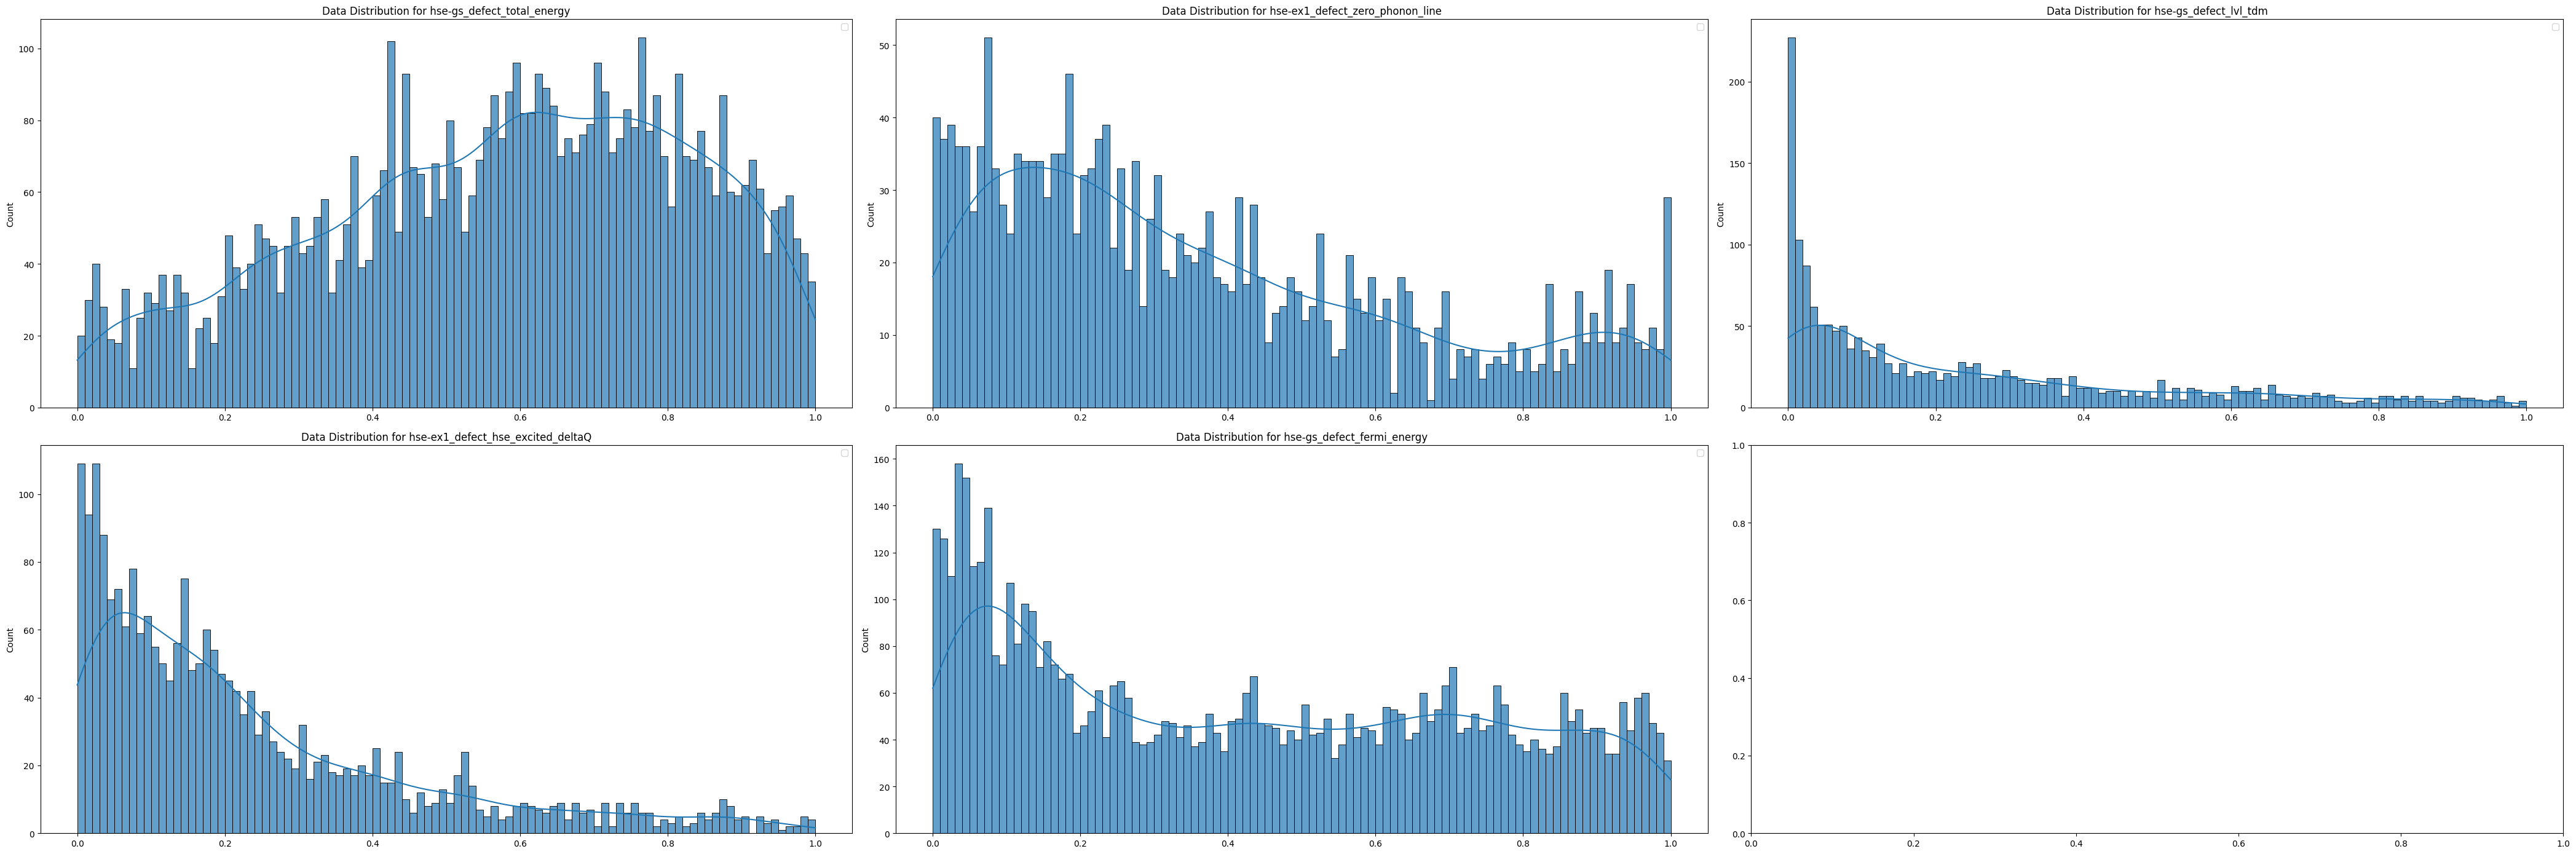

In [42]:
import math



def dataDistributions(label_list, save=False):
    if not isinstance(label_list, list):
        label_list = [label_list]  # If single tuple, wrap in list
    
    cols = 3
    rows = math.ceil(len(label_list) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14 * cols, 7 * rows))
    axes = axes.flatten()[:len(label_list)]  # Flatten and slice to match number of plots
    
    for i, (label1, label2) in enumerate(label_list):
        data_val = np.load(f'filtered_data/{label1}_{label2}_y_val.npy')
        data_train = np.load(f'filtered_data/{label1}_{label2}_y_train.npy')

        data = np.concatenate((data_val, data_train), axis=0)
        
        ax = axes[i]
        sns.histplot(data, bins=100, kde=True, ax=ax, alpha=0.7)
        ax.set_title(f'Data Distribution for {label1}_{label2}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()




dataDistributions([('hse-gs', 'defect_total_energy'), 
                    ("hse-ex1", "defect_zero_phonon_line"), 
                    ('hse-gs', 'defect_lvl_tdm'),
                    ('hse-ex1', 'defect_hse_excited_deltaQ'),
                    ('hse-gs', 'defect_fermi_energy')], save=False)


# powers = []

# for label1, label2, version in [('hse-gs', 'defect_total_energy', '2.1'), 
#                                 ("hse-ex1", "defect_zero_phonon_line", "2.0"), 
#                                 ('hse-gs', 'defect_lvl_tdm', '2.0'),
#                                 ('hse-ex1', 'defect_hse_excited_deltaQ', '2.0'),
#                                 ('hse-gs', 'defect_fermi_energy', '2.0')]:
#     powers.append(computePowers(label1, label2, version, save=True))

# print(powers)
# # Labels for the bars
# labels = ['Defect Energy', 'Zero Phonon Line', 'Level TDM', 'HSE Excited Delta Q', 'Fermi Energy']

# # Extract mean and val powers
# mean_powers = [p[0] for p in powers]
# val_powers = [p[1] for p in powers]

# # Create horizontal bar plot
# fig, ax = plt.subplots(figsize=(10, 6))
# y_pos = range(len(labels))

# ax.barh([y + 0.3 for y in y_pos], [1] * len(labels), height=0.3, label='Random Guess', color='lightgray')
# ax.barh([y for y in y_pos], mean_powers, height=0.3, label='Mean Guess', color='skyblue')
# ax.barh([y - 0.3 for y in y_pos], val_powers, height=0.3, label='GNN Prediction', color='lightgreen')
# ax.set_yticks(y_pos)
# ax.set_yticklabels(labels, fontsize=20)
# ax.set_xlabel('1 / Normalized Error', fontsize=22)
# ax.set_title('Predictive Power', fontsize=24)
# ax.tick_params(axis='x', labelsize=20)
# ax.legend(fontsize=20)
# plt.tight_layout()
# plt.savefig('pictures/predictive_power.png', dpi=300)
# plt.show()